# Tarea 1: Predicción de resultados del fútbol uruguayo

Este notebook construye modelos para predecir si gana el equipo local (`L`), gana el visitante (`V`) o termina en empate (`E`). El flujo se ejecuta en orden desde la carga del archivo hasta la comparaci?n entre un ?rbol de decisi?n y un bosque aleatorio.

## Preprocesamiento

--- 
### 1. Preparación y carga de los datos

Se importan las librerías utilizadas durante el análisis y se define la ubicación del archivo CSV. La celda de instalación es opcional: solo debe ejecutarse si alguna dependencia no está disponible en el entorno local.


In [18]:
# Ejecutar solo si faltan dependencias en el entorno actual
# %pip install pandas numpy matplotlib scikit-learn

In [19]:
from functions import load_csv

dataset = load_csv.load()

Cantidad inicial de instancias: 15207
Cantidad inicial de atributos: 17


### Descripción de los atributos:

| Atributo | Descripción |
| :--- | :--- |
| **`home`** | Nombre del equipo local (no necesariamente único) |
| **`away`** | Nombre del equipo visitante (no necesariamente único) |
| **`date`** | Fecha del partido |
| **`gh`** | Goles del equipo local (incluyendo tiempo extra y penales) |
| **`ga`** | Goles del equipo visitante (incluyendo tiempo extra y penales) |
| **`full_time`** | "F"=el partido terminó en 90', "E"=tiempo extra, "P"=penales |
| **`competition`** | Nombre del país de la liga o nombre de la competición int. |
| **`home_ident`** | Identificador único del equipo local |
| **`away_ident`** | Identificador único del equipo visitante |
| **`home_country`** | País del equipo local |
| **`away_country`** | País del equipo visitante |
| **`home_code`** | Código de país del equipo local |
| **`away_code`** | Código de país del equipo visitante |
| **`home_continent`** | Continente del equipo local |
| **`away_continent`** | Continente del equipo visitante |
| **`continent`** | Continente de la competición |
| **`level`** | "national"= liga local, "international"= copa internacional |

---
### 1. Eliminación de duplicados

In [20]:
from functions import remove_duplicates

dataset = remove_duplicates.remove(dataset)

Duplicados eliminados: 1
Instancias restantes: 15206


--- 
### 2. Definición de la Variable Objetivo (`ganador`)

El objetivo del modelo es predecir el resultado final de un partido de fútbol, clasificándolo en una de tres categorías posibles: victoria local, victoria visitante o empate.

Dado que el dataset original no incluye directamente una columna de resultado, se deduce la variable objetivo **`ganador`** mediante la comparación de los goles anotados por el equipo local (`gh`) y el visitante (`ga`):

* Si $\text{gh} > \text{ga} \implies$ **`L`**
* Si $\text{ga} > \text{gh} \implies$ **`V`**
* Si $\text{gh} == \text{ga} \implies$ **`E`**

In [21]:
from functions import calculate_objective_var

dataset = calculate_objective_var.calculate(dataset)

Una vez creada la variable ganador, los atributos `gh` y `ga` dejan de ser necesarios como entrada directa al modelo, ya que toda la información que contienen quedó capturada en la nueva columna. Sin embargo, estos valores de goles aún serán utilizados en una etapa posterior para construir atributos históricos de cada equipo —como la cantidad de goles anotados y recibidos en sus últimos partidos— por lo que su eliminación del dataset se realizará recién una vez que esos cálculos hayan sido completados.

--- 
### 3. Selección de Atributos

En esta etapa del preprocesamiento se realiza una selección de los atributos del dataset con el objetivo de maximizar la capacidad de aprendizaje del modelo. Para ello, se examina cada atributo de forma individual para evaluar si contribuye de manera significativa al entrenamiento o si, dadas sus características, puede ser removido sin perjudicar el desempeño del modelo.

Se evalúan las siguientes condiciones de los atributos:

* **Atributos constantes:** No contribuyen al aprendizaje del modelo debido a que mantienen el mismo valor para todas las instancias del dataset (varianza cero).
* **Atributos redundantes:** Representan valores equivalentes dentro del dataset, por lo que basta con conservar uno de ellos.

Posteriormente, estos atributos se excluyen del dataset para que no formen parte del entrenamiento del modelo.

#### A. Detección de Atributos Constantes

In [22]:
from functions import remove_constant_features

dataset = remove_constant_features.remove(dataset)

Atributos constantes detectados:
competition       1
home_country      1
away_country      1
home_code         1
away_code         1
home_continent    1
away_continent    1
continent         1
level             1
dtype: int64


Los atributos constantes son los siguientes:
* `competition`, `home_country`, `away_country` (Todos refieren a Uruguay).
* `home_code`, `away_code` (Código constante `UY`).
* `home_continent`, `away_continent`, `continent` (Todos refieren a `South America`).
* `level` (Constante con el valor `national`).

#### B. Detección de Atributos Redundantes

In [23]:
from functions import remove_redundant_features

dataset = remove_redundant_features.remove(dataset)

Cada valor de home se corresponde a un solo valor de home_ident, y viceversa:  True
Cada valor de away se corresponde a un solo valor de away_ident, y viceversa:  True


Existe una correspondencia 1:1, mantener ambas variables introduciría información redundante. Elegimos quedarnos con `home` y `away` y se descartan sus identificadores (`home_ident` y `away_ident`).

**Obervación**: La aplicación de este método "a mano" para identificar a los atributos redundantes es más que suficiente para el dataset con el que estamos trabajando, sin embargo, si se tratara de un dataset con una cantidad más grande de atributos entonces sería necesario automatizar de alguna forma la identificación de los atributos redundantes.

---
### 4. Descomposición del atributo `date`

El atributo `date` se divide en los atributos `day_of_week`, `day`, `month` y `year` para representar sus componentes por separado. Esta transformación facilita que el modelo identifique patrones relacionados con el momento del año en que se disputó el partido, como diferencias entre meses, temporadas o períodos históricos. Además, evita tratar cada fecha completa como un valor independiente, lo que podría dificultar el aprendizaje. 

Por otro lado, el atributo `year` es necesario para poder dividir el dataset de la forma indicada, más adelante.
El atributo `date` se preserva por el momento porque lo utilizaremos más adelante con el objetivo de ordenar el dataset de forma cronológica para crear atributos históricos.
Por último, se realiza la conversión de día del mes `day` a día de la semana `day_of_week`.

In [24]:
import pandas as pd

dataset["date"] = pd.to_datetime(dataset["date"])
dataset["day_of_week"] = dataset["date"].dt.day_name()
dataset["day"] = dataset["date"].dt.day
dataset["month"] = dataset["date"].dt.month
dataset['year'] = dataset['date'].dt.year

---
### 5. Creación de atributos históricos

Para cada equipo (local y visitante) se calculan los siguientes atributos históricos:

* Cantidad de goles anotados en los últimos 10 partidos
* Cantidad de goles recibidos en los últimos 10 partidos
* Días de descanso desde el último partido jugado

Estas variables se calculan ordenando los partidos por fecha y agrupándolos por temporada (año) y equipo. De esta forma, los atributos se calculan en base a una misma temporada.

**Observación**: En el caso de los días de descanso para un equipo que jugará su primera fecha en el campeonato, se asigna un valor por defecto que representa una cantidad estándar de días de descanso desde el último partido disputado en la temporada anterior.

In [25]:
from functions import calculate_historic_features

dataset = calculate_historic_features.calculate(dataset)

Posteriormente, se eliminan las columnas que ya cumplieron su función en el preprocesamiento. `gh` y `ga` fueron utilizados para calcular las rachas de goles, por lo que ya no aportan información adicional al modelo. `date` fue descompuesta en `day_of_week` y `month`, y utilizada para calcular dias_descanso, por lo que su presencia es ahora redundante.

In [26]:
dataset = dataset.drop(columns=['gh', 'ga', 'date'])

---
### 6. Análisis de Balance

In [27]:
# Cálculo de la dispersión de instancias respecto a las clases
porcentajes = dataset["ganador"].value_counts(normalize=True).mul(100).round(2)

instancias_L = float(porcentajes.iloc[0])
instancias_V = float(porcentajes.iloc[1])
instancias_E = float(porcentajes.iloc[2])

print(f"Porcentaje de instancias correspondientes a la clase L: ", instancias_L)
print(f"Porcentaje de instancias correspondientes a la clase V: ", instancias_V)
print(f"Porcentaje de instancias correspondientes a la clase E: ", instancias_E)

Porcentaje de instancias correspondientes a la clase L:  44.36
Porcentaje de instancias correspondientes a la clase V:  28.21
Porcentaje de instancias correspondientes a la clase E:  27.44


La distribución de la variable objetivo muestra que las victorias del equipo local son notablemente más frecuentes que los empates o las victorias visitantes. Este es un dato que acompaña a la intuición que se tiene desde el conocimiento del mundo real.

---
### 7. División del Conjunto de Datos

Los datos disponibles se separan en dos conjuntos: uno de **entrenamiento**, con todos los partidos jugados hasta el año 2023 inclusive, y uno de **evaluación**, con los partidos de 2024 y 2025.

Esta división respeta el orden cronológico de los datos: el modelo aprende a partir de partidos del pasado y se evalúa únicamente con partidos que no vio durante el entrenamiento. Dividir los datos de forma aleatoria no sería apropiado en este caso, ya que mezclar partidos de distintas épocas podría hacer que el modelo aprenda de información de partidos futuros para predecir partidos ocurridos en el pasado.

Se resuelve eliminar el atributo `year` como entrada al modelo luego de realizada la división del conjunto de datos. Durante la construcción del modelo como árbol de decisión se pueden crear subatributos del tipo `year < 2010`, que tienen sentido dentro del rango de años conocidos. Sin embargo, dado que estamos trabajando con una partición temporal, al realizar la evaluación todos los partidos corresponden a 2024 y 2025 —años nunca vistos durante el entrenamiento— por lo que caerían siempre en la misma rama residual del árbol, independientemente de las características reales del partido.

In [28]:

# Instancias con partidos jugados hasta el año 2023 inclusive
df_entrenamiento = dataset[dataset['year'] <= 2023]
X_train = df_entrenamiento.drop(columns=['ganador', 'year'])
Y_train = df_entrenamiento['ganador']

df_evaluacion = dataset[dataset['year'] > 2023]
X_test = df_evaluacion.drop(columns=['ganador', 'year'])
Y_test = df_evaluacion['ganador']

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Evaluación):    {X_test.shape}")

Dimensiones de X_train (Entrenamiento): (14734, 12)
Dimensiones de X_test (Evaluación):    (472, 12)


---
### 8. Construcción del Pipeline de Procesamiento y Entrenamiento

Un pipeline es una estructura que encadena de forma ordenada todos los pasos de procesamiento de datos y entrenamiento del modelo en un único objeto. Esto garantiza que cada vez que se ejecute, el proceso sea exactamente el mismo y completamente reproducible, sin depender del orden en que se corran las celdas.

El pipeline se organiza en dos bloques principales:

**Preprocesamiento**: maneja de forma diferenciada los atributos numéricos y los categóricos.

**Clasificador**: el modelo de árbol de decisión, que recibe los datos ya procesados y aprende a partir de ellos.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer


numeric_features = ['month', 'racha_goles_recibidos_home', 'racha_goles_anotados_home',
                    'dias_descanso_home', 'dias_descanso_away','racha_goles_recibidos_away',
                    'racha_goles_anotados_away']
categorical_features = ['home', 'away', 'full_time', 'day_of_week']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(fill_value='missing', strategy='constant')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))],
)

preprocessing = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features),
    ],
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

pipeline_dt = Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state=62))
])

pipeline_rf = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=62))
])

---
### 9. Búsqueda y Ajuste de Hiperparámetros

Los hiperparámetros evaluados son:

* `strategy` del imputador numérico: define si los valores faltantes se reemplazan por la media o la mediana del atributo correspondiente.
* `max_depth`: profundidad máxima del árbol de decisión.
* `criterion`: criterio con el que el árbol decide cómo dividir los datos en cada paso (gini o entropy).
* `min_impurity_decrease`: umbral mínimo de ganancia de información que debe producir una división para que el árbol continúe ramificándose. Cuando ningún atributo supera este umbral en un nodo, el árbol se detiene. Este parámetro es el equivalente en scikit-learn al hiperparámetro `min_info_gain` solicitado.

In [31]:
param_grid_dt = {
    # Preprocesamiento numérico
    'preprocessing__numeric__imputer__strategy': [
        'mean',
        'median'
    ],
    # Árbol de decisión
    'model__max_depth': [
        3,
        6,
        10,
        15,
        None
    ],
    'model__criterion':[
        'gini','entropy'
    ],
    # Minima ganancia permitida para un atributo
    'model__min_impurity_decrease': [
        0.0,
        0.001,
        0.005,
        0.01,
        0.05
    ]
}

param_grid_rf = {
    # Preprocesamiento numérico
    'preprocessing__numeric__imputer__strategy': [
        'mean',
        'median'
    ],
    # Random Forest
    'model__n_estimators': [
        100,
        200,
        300
    ],
    'model__max_depth': [
        5,
        10,
        20,
        None
    ],
    # Atributos considerados por árbol en cada división
    'model__max_features': [
        'sqrt',
        'log2'
    ],
    # Mínima ganancia permitida para un atributo
    'model__min_impurity_decrease': [
        0.0,
        0.001,
        0.005
    ]
}

Para evaluar cada combinación sin utilizar el conjunto de evaluación final, se emplea validación cruzada con partición temporal (`TimeSeriesSplit`). A diferencia de la validación cruzada tradicional —donde los datos se mezclan aleatoriamente para formar los distintos subconjuntos de validación—, este método lo que hace es que en cada ronda el modelo siempre entrene con partidos anteriores a los que se usan para validar. Esto evita que se mezclen partidos de distintas épocas, sino el modelo podría entrenarse con información de partidos que ocurrieron después de los que intenta predecir, lo cual no reflejaría un escenario real.

In [32]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cv_temporal = TimeSeriesSplit(n_splits=10)

grid_search_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring='accuracy',
    cv=cv_temporal,
    n_jobs=-1,
    refit=True
)

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=cv_temporal,
    n_jobs=-1,
    refit=True
)

grid_search_dt.fit(X_train, Y_train)
grid_search_rf.fit(X_train, Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=62))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_impurity_decrease': [0.0, 0.001, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-

### 10. Evaluación y Comparación de Resultados

Una vez completada la búsqueda de hiperparámetros, esta sección analiza los resultados
obtenidos en tres pasos: primero se visualiza cómo varía el error según cada hiperparámetro,
luego se presentan las métricas de evaluación sobre el conjunto de test, y finalmente
se muestra la matriz de confusión de cada modelo.

Dado que ambos `GridSearchCV` fueron configurados con `refit=True`, los modelos ya fueron
reentrenados automáticamente con los mejores hiperparámetros encontrados sobre el conjunto
de entrenamiento completo. No es necesario un paso de reentrenamiento explícito.

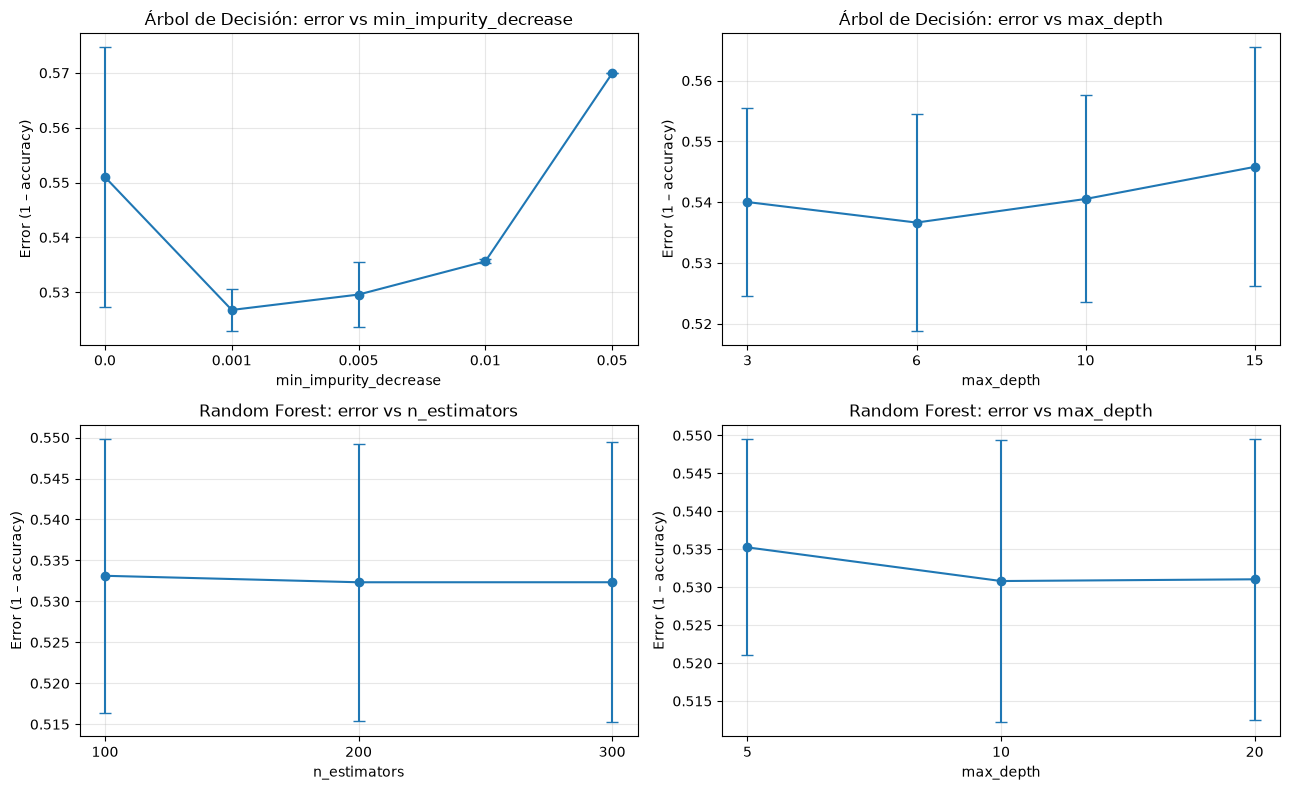

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

results_dt = pd.DataFrame(grid_search_dt.cv_results_)
results_rf = pd.DataFrame(grid_search_rf.cv_results_)

def plot_param(ax, results, col, title, xlabel, order):
    df = results.copy()
    df['_x'] = df[col].astype(str)
    g = df.groupby('_x')['mean_test_score']
    means = g.mean().reindex([str(x) for x in order])
    stds  = g.std().reindex([str(x) for x in order]).fillna(0)
    ax.errorbar(means.index, 1 - means.values, yerr=stds.values,
                marker='o', capsize=4, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Error (1 – accuracy)')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_param(axes[0, 0], results_dt,
           'param_model__min_impurity_decrease',
           'Árbol de Decisión: error vs min_impurity_decrease',
           'min_impurity_decrease',
           order=[0.0, 0.001, 0.005, 0.01, 0.05])

plot_param(axes[0, 1], results_dt,
           'param_model__max_depth',
           'Árbol de Decisión: error vs max_depth',
           'max_depth',
           order=[3, 6, 10, 15, None])

plot_param(axes[1, 0], results_rf,
           'param_model__n_estimators',
           'Random Forest: error vs n_estimators',
           'n_estimators',
           order=[100, 200, 300])

plot_param(axes[1, 1], results_rf,
           'param_model__max_depth',
           'Random Forest: error vs max_depth',
           'max_depth',
           order=[5, 10, 20, None])

plt.tight_layout()
plt.show()

In [34]:
def format_params(gs):
    return {
        k.replace('preprocessing__numeric__imputer__', '')
         .replace('model__', ''): v
        for k, v in gs.best_params_.items()
    }

display(pd.DataFrame({
    'Árbol de Decisión': format_params(grid_search_dt),
    'Random Forest':     format_params(grid_search_rf),
}))

,Árbol de Decisión,Random Forest
criterion,gini,NaN
max_depth,6,10
min_impurity_decrease,0.001,0.0
strategy,mean,mean
max_features,NaN,sqrt
n_estimators,NaN,200


#### Métricas de evaluación sobre el conjunto de test

Se evalúan ambos modelos sobre los partidos de 2024 y 2025. La tabla resumen presenta
accuracy y macro-F1; el reporte detallado desglosa precisión, recall y F1 por cada clase.

El **macro-F1** promedia el F1 de las tres clases sin tener en cuenta su frecuencia,
por lo que penaliza de forma equitativa los errores en clases poco representadas como
empates y victorias visitantes.

In [35]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_dt = grid_search_dt.predict(X_test)
y_pred_rf = grid_search_rf.predict(X_test)

resumen = pd.DataFrame([
    {
        'Modelo':        'Árbol de Decisión',
        'Accuracy CV':   round(float(grid_search_dt.best_score_), 4),
        'Accuracy Test': round(float(accuracy_score(Y_test, y_pred_dt)), 4),
        'Macro-F1 Test': round(float(f1_score(Y_test, y_pred_dt, average='macro')), 4),
    },
    {
        'Modelo':        'Random Forest',
        'Accuracy CV':   round(float(grid_search_rf.best_score_), 4),
        'Accuracy Test': round(float(accuracy_score(Y_test, y_pred_rf)), 4),
        'Macro-F1 Test': round(float(f1_score(Y_test, y_pred_rf, average='macro')), 4),
    },
])
display(resumen)

print("=== Árbol de Decisión ===")
print(classification_report(Y_test, y_pred_dt))

print("=== Random Forest ===")
print(classification_report(Y_test, y_pred_rf))

,Modelo,Accuracy CV,Accuracy Test,Macro-F1 Test
0,Árbol de Decisión,0.4784,0.4492,0.3126
1,Random Forest,0.4935,0.4555,0.3202


=== Árbol de Decisión ===
              precision    recall  f1-score   support

           E       0.00      0.00      0.00       131
           L       0.44      0.91      0.59       190
           V       0.51      0.26      0.35       151

    accuracy                           0.45       472
   macro avg       0.31      0.39      0.31       472
weighted avg       0.34      0.45      0.35       472

=== Random Forest ===
              precision    recall  f1-score   support

           E       0.00      0.00      0.00       131
           L       0.43      0.92      0.59       190
           V       0.59      0.27      0.37       151

    accuracy                           0.46       472
   macro avg       0.34      0.40      0.32       472
weighted avg       0.36      0.46      0.36       472



C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

#### Matrices de confusión

Cada celda muestra cuántas instancias del conjunto de evaluación fueron clasificadas en cada combinación de clase real (filas) y clase predicha (columnas). Los valores en la diagonal corresponden a predicciones correctas; los que están fuera indican el tipo de error cometido.

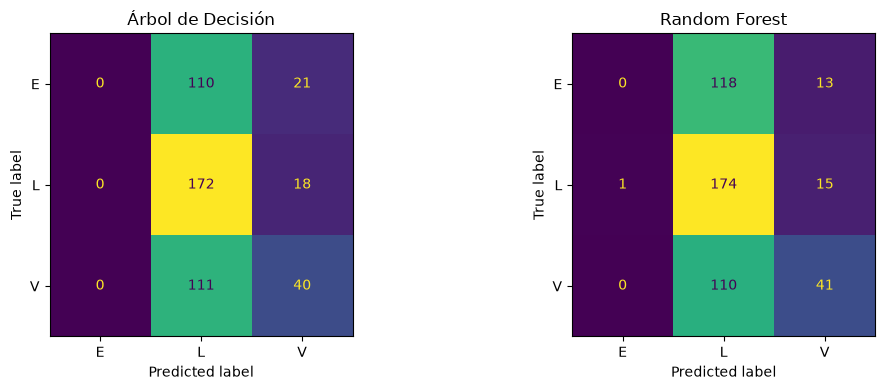

In [36]:
clases = sorted(Y_test.unique())   # ['E', 'L', 'V']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_dt,
    display_labels=clases, ax=axes[0], colorbar=False
)
axes[0].set_title('Árbol de Decisión')

ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_rf,
    display_labels=clases, ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()